# Setup

In [1]:
# Installing BERTopic
!pip install bertopic

# Importing all needed packages
from google.colab import drive
from google.colab import files
import os, random, numpy as np, torch
from bertopic import BERTopic
from sklearn.cluster import KMeans
import pandas as pd
from umap import UMAP
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

# Forcing determinism
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.3 MB/s eta 0:00:00


# Loading data

In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
df_orig = pd.read_csv("/content/drive/My Drive/Review.csv")

In [4]:
# Extracting titles and abstracts as text sources
raw_docs = (df_orig["Title"].astype(str) + " " + df_orig["Abstract Note"].astype(str)).tolist()

In [5]:
# Checking amount of papers
print(f"Amount: {len(raw_docs)}")

Amount: 1448


# Model init

In [6]:
# Dimensionality Reduction with UMAP
umap_model = UMAP(
    n_neighbors=10,
    n_components=8,
    min_dist=0.0,
    metric="cosine",
    random_state=42)

# Clustering with kmeans
cluster_model = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10)

# Vectorizer model
vectorizer_model = CountVectorizer(
    min_df=5,
    max_df=0.85)

# Topic representation with ctfidf model
ctfidf_model = ClassTfidfTransformer(
    bm25_weighting=True,
    reduce_frequent_words=True)

# Setting up the model
topic_model = BERTopic(
    embedding_model="all-mpnet-base-v2",
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    )

In [7]:
# Model fitting
topics, probs = topic_model.fit_transform(raw_docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Results

In [8]:
# Get topic info
topic_info = topic_model.get_topic_info()

# Add percentage
total = topic_info['Count'].sum()
topic_info['Percentage'] = np.round(topic_info['Count'] / total * 100,2)

# Choose number of words in representation
topic_info["Representation"] = topic_info["Representation"].apply(
    lambda x: ", ".join(x[:3]))

topic_info

,Topic,Count,Name,Representation,Representative_Docs,Percentage
0,0,147,0_park_sports_parks_catchment,"park, sports, parks",[A multi-mode Gaussian-based two-step floating...,10.15
1,1,119,1_healthcare_medical_care_hospitals,"healthcare, medical, care",[Spatiotemporal disparities in maternal mortal...,8.22
2,2,108,2_transport_rail_transit_bus,"transport, rail, transit",[Future accessibility impacts of transport pol...,7.46
3,3,95,3_tehran_territorial_segregation_densification,"tehran, territorial, segregation",[DECENTRALIZATION OF INTER-BUDGET RELATIONS: T...,6.56
4,4,94,4_greenspace_gentrification_canopy_cover,"greenspace, gentrification, canopy","[Environmental Injustice, Tree Canopy Cover, a...",6.49
5,5,87,5_greenspace_greenery_street_view,"greenspace, greenery, street",[Identification of Inequities in Green Visibil...,6.01
6,6,86,6_carbon_ugss_es_ugs,"carbon, ugss, es",[Environmental effects and spatial inequalitie...,5.94
7,7,76,7_gardens_tree_trees_ecosystem,"gardens, tree, trees",[Contributions to a global understanding of so...,5.25
8,8,75,8_pm2_air_pollution_concentrations,"pm2, air, pollution",[Changes in Socioeconomic Disparities for Traf...,5.18
9,9,66,9_recreation_european_ugs_outdoor,"recreation, european, ugs",[Environmental justice in a very green city: S...,4.56


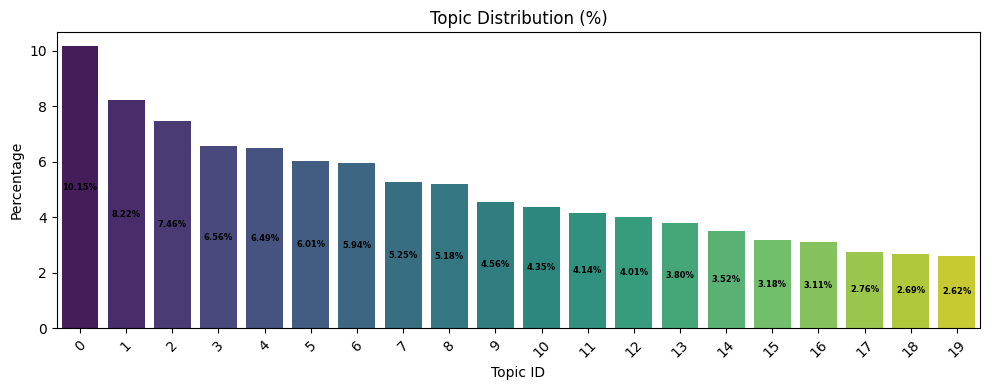

In [9]:
# Sort topics by percentage (optional, for readability)
df_sorted = topic_info.sort_values("Percentage", ascending=False)

plt.figure(figsize=(10,4))
ax = sns.barplot(x="Topic", y="Percentage", data=df_sorted, palette="viridis")

# Annotate inside bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha="center", va="center", fontsize=6, color="black", weight="bold")

plt.title("Topic Distribution (%)")
plt.ylabel("Percentage")
plt.xlabel("Topic ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization

In [28]:
# Get embeddings
#embeddings = topic_model.embedding_model.embed(raw_docs)

# Reduce dimensionality of embeddings (for less runtime)
#reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

# Applying custom labels for readability
custom_labels = {
    0: "1_Politics and procedures",
    1: "2_Healthcare and medical facilities",
    2: "3_Transport and mobility",
    3: "4_Spatial disparities of UGS",
    4: "5_Parks",
    5: "6_Trees, tree canopy, vegetation",
    6: "7_UGS proximity and availability",
    7: "8_Pollution",
    8: "9_Street trees, urban forests, and collaborative greening",
    9: "10_Residential greenspace exposure and green view",
    10: "11_2SFCA and related methods",
    11: "12_Distribution of essential and emergency services",
    12: "13_Temperature and energy infrastructure",
    13: "14_Cycling, sharing mobility, and e-mobility",
    14: "15_UGS accessibility for racialised populations",
    15: "16_Accessibility of public amenities, social, and cultural facilities",
    16: "17_Environmental health",
    17: "18_Public services, elderly care and community facilities",
    18: "19_Environmental hazards and risk management",
    19: "20_Schools and other educational facilities",
}

topic_model.set_topic_labels(custom_labels)

# Visualize documents
fig = topic_model.visualize_documents(
    raw_docs,
    reduced_embeddings=reduced_embeddings,
    custom_labels=True,         # For version without custom labels: set to False
    hide_document_hover=True
)

fig.show()

# Qualitative sampling (medoids)

In [11]:
# Create medoids
n_medoid = 3
topics_array = np.array(topics)

poster_children = []
topic_topn_lookup = {}

for topic_id in sorted(set(topics_array)):
    doc_indices = np.where(topics_array == topic_id)[0]
    topic_embs = embeddings[doc_indices]

    if len(doc_indices) == 0:
        continue

    # Cosine similarity via cosine distance
    sims = 1 - pairwise_distances(topic_embs, metric="cosine")
    avg_sims = sims.mean(axis=1)

    ranked_local = np.argsort(-avg_sims)
    top_local = ranked_local[:n_medoid]

    top_titles = []

    for rank, local_idx in enumerate(top_local, start=1):
        global_idx = doc_indices[local_idx]

        poster_children.append((global_idx, rank))

poster_lookup = {doc_idx: rank for doc_idx, rank in poster_children}

In [12]:
# Create lookups
poster_lookup = {doc_idx: rank for doc_idx, rank in poster_children}

topic_info = topic_model.get_topic_info()
topic_name_lookup = {
    topic_id: ", ".join([word for word, _ in topic_model.get_topic(topic_id)[:3]])
    for topic_id in topic_info["Topic"]
}

topic_rep_lookup = {}

for topic_id in topic_info["Topic"]:
    words = topic_model.get_topic(topic_id)
    representation = ", ".join([word for word, _ in words[:5]])
    topic_rep_lookup[topic_id] = representation

In [16]:
# Create csv
rows = []

for idx, row in df_orig.iterrows():

    topic_id = topics_array[idx]

    rows.append({
        "Title": row["Title"],
        "Topic_ID": topic_id,
        "Topic_Name": topic_name_lookup.get(topic_id, ""),
        "Topic_Representation": topic_rep_lookup.get(topic_id, ""),
        "Medoid_Rank": poster_lookup.get(idx, "")
    })

df_csv = pd.DataFrame(rows)

df_csv = df_csv.sort_values(
    ["Topic_ID", "Medoid_Rank"],
    ascending=[True, True]
).reset_index(drop=True)

csv_path = "papers_with_topics_and_medoids.csv"
df_csv.to_csv(csv_path, index=False)

files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test section

Silhouette score:

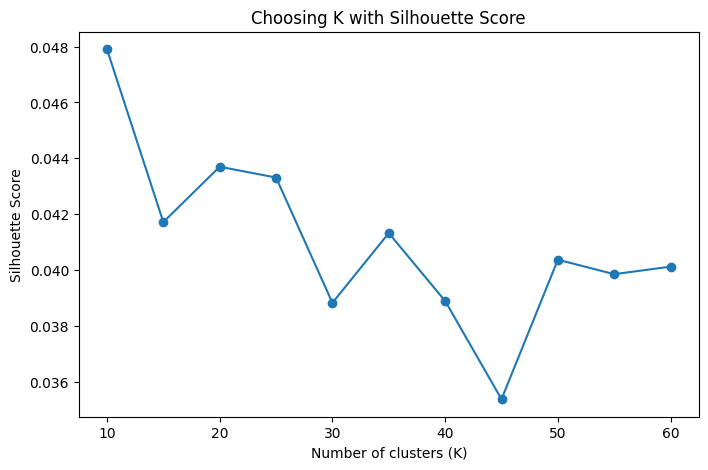

Best K according to silhouette score: 10


In [14]:
# Testing for optimal number of topics with silhouette score

k_values = range(10, 61, 5)  # Test K from 10 to 60
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    sil_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Choosing K with Silhouette Score")
plt.show()

# Best K
best_k = k_values[np.argmax(sil_scores)]
print("Best K according to silhouette score:", best_k)


ARI Score March - April:


In [17]:
uploaded = files.upload()

march = pd.read_csv("march.csv")
april = pd.read_csv("april.csv")

Saving april.csv to april.csv
Saving march.csv to march.csv


In [18]:
# Keep only relevant columns
march = march[['Title', 'Topic_ID']]
april = april[['Title', 'Topic_ID']]

# Merge on Title
merged = pd.merge(
    march,
    april,
    on="Title",
    how="inner",
    suffixes=("_march", "_april")
)

# Drop missing values if any
merged = merged.dropna(subset=["Topic_ID_march", "Topic_ID_april"])

# Ensure consistent ordering
merged = merged.sort_values("Title").reset_index(drop=True)

merged.head()

,Title,Topic_ID_march,Topic_ID_april
0,"""We Called It 'Cancer Park'"": Soil Contaminati...",7,8
1,'Green or short: choose one' - A comparison of...,6,9
2,"(Counter)mapping renewables: Space, justice, a...",16,17
3,(In)Equitable Accessibility to Sustainable Tra...,2,2
4,3-30-300 RULE: ADAPTATION TO A PERUVIAN COASTA...,8,7


In [19]:
# Get Adjusted Rand Score
ari = adjusted_rand_score(
    merged["Topic_ID_march"],
    merged["Topic_ID_april"]
)

print(f"Adjusted Rand Index (March vs April): {ari:.4f}")

Adjusted Rand Index (March vs April): 0.7742
